In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv("/content/household_energy_consumption.csv")

In [5]:
df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
print("First 5 rows:")
print(df.head())

First 5 rows:
  Household_ID        Date  Energy_Consumption_kWh  Household_Size  \
0       H00001  2025-04-01                     8.4               4   
1       H00001  2025-04-02                     7.9               4   
2       H00001  2025-04-03                     9.2               4   
3       H00001  2025-04-04                     7.9               4   
4       H00001  2025-04-05                     9.6               4   

   Avg_Temperature_C Has_AC  Peak_Hours_Usage_kWh  
0               17.8     No                   3.2  
1               17.3     No                   2.8  
2               18.6     No                   3.0  
3               18.2     No                   2.7  
4               11.9     No                   3.2  


In [8]:
print("\nDataset shape:")
print(df.shape)


Dataset shape:
(90000, 7)


In [9]:
print("\nDataset information:")
print(df.info())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            90000 non-null  object 
 1   Date                    90000 non-null  object 
 2   Energy_Consumption_kWh  90000 non-null  float64
 3   Household_Size          90000 non-null  int64  
 4   Avg_Temperature_C       90000 non-null  float64
 5   Has_AC                  90000 non-null  object 
 6   Peak_Hours_Usage_kWh    90000 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 4.8+ MB
None


In [10]:
print("\nStatistical summary:")
print(df.describe())


Statistical summary:
       Energy_Consumption_kWh  Household_Size  Avg_Temperature_C  \
count            90000.000000    90000.000000       90000.000000   
mean                10.571988        3.487811          17.505802   
std                  5.519494        1.709761           2.491621   
min                  0.500000        1.000000          10.000000   
25%                  6.000000        2.000000          15.800000   
50%                 10.400000        3.000000          17.500000   
75%                 14.800000        5.000000          19.200000   
max                 20.000000        6.000000          25.000000   

       Peak_Hours_Usage_kWh  
count          90000.000000  
mean               4.319557  
std                2.531432  
min                0.200000  
25%                2.300000  
50%                4.000000  
75%                6.000000  
max               10.000000  


In [11]:
df=df.dropna()

In [12]:
x=df[["Household_Size","Avg_Temperature_C","Peak_Hours_Usage_kWh"]]

In [13]:
y=df[["Energy_Consumption_kWh"]]

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4)

In [15]:
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [16]:
model=LinearRegression()
model.fit(x_train_poly,y_train)

LinearRegression()

In [17]:
y_pred=model.predict(x_test_poly)

In [18]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=mse ** 0.5
r2=r2_score(y_test,y_pred)

In [19]:
print("\nPolynomial Regression Results")


Polynomial Regression Results


In [20]:
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)


MAE: 0.5641089635852748
MSE: 0.5152235533373055
RMSE: 0.7177907448116795


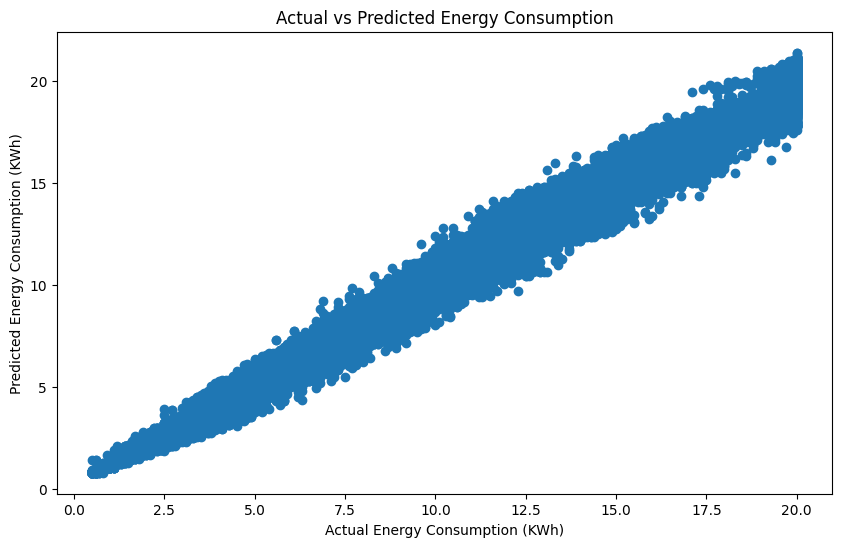

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Energy Consumption (KWh)")
plt.ylabel("Predicted Energy Consumption (KWh)")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()